# Plot Validity: Jacobian & Hessian per event, per parameter

Loads precomputed results from `compute_taylor_scan.ipynb` and generates plots.
No GPU or simulation code needed here.

In [1]:
import os, sys, pickle
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 13})


def load_results(path):
    with open(path, 'rb') as f:
        return pickle.load(f)


def compute_validity_range(mean_true, mean_approx, rel_deltas, threshold):
    """Find asymmetric perturbation range where |approx - true| < threshold.
    Uses linear interpolation between grid points for exact crossing."""
    pct = rel_deltas * 100
    error = np.abs(mean_approx - mean_true)
    idx_nom = np.argmin(np.abs(rel_deltas))

    # Search left from nominal
    pct_lo = pct[0]
    for i in range(idx_nom - 1, -1, -1):
        if error[i] > threshold:
            # Crossing is between i (above) and i+1 (below)
            frac = (threshold - error[i + 1]) / (error[i] - error[i + 1] + 1e-30)
            pct_lo = pct[i + 1] + frac * (pct[i] - pct[i + 1])
            break

    # Search right from nominal
    pct_hi = pct[-1]
    for i in range(idx_nom + 1, len(pct)):
        if error[i] > threshold:
            # Crossing is between i-1 (below) and i (above)
            frac = (threshold - error[i - 1]) / (error[i] - error[i - 1] + 1e-30)
            pct_hi = pct[i - 1] + frac * (pct[i] - pct[i - 1])
            break

    return (float(pct_lo), float(pct_hi))


## Configuration

In [2]:
RESULTS_FILE = 'taylor_scan_results.pkl'
THRESHOLDS = [0.1, 0.5]  # ADC error thresholds for validity range

## Load results

In [3]:
results = load_results(RESULTS_FILE)
param_names = list(results.keys())
event_ids = sorted(next(iter(results.values())).keys())
print(f'Parameters: {param_names}')
print(f'Events: {event_ids}')

Parameters: ['Ab']
Events: [3, 5, 10, 18, 23, 30, 43, 50, 51, 62, 63, 67, 68]


## Per-parameter: mean ADC curves

For each parameter, one subplot per event showing true / Jacobian / Hessian.

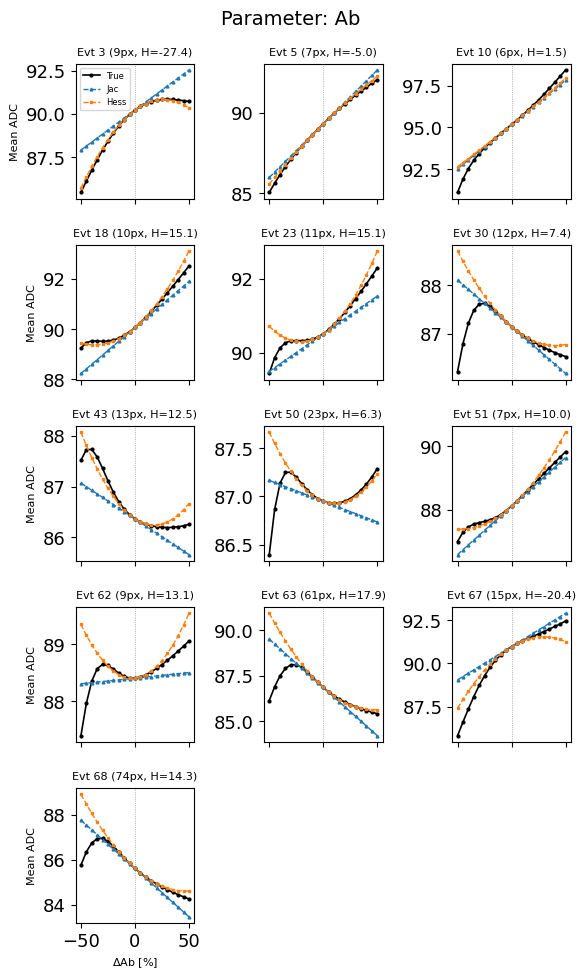

In [4]:
for param_name in param_names:
    param_results = results[param_name]
    eids = sorted(param_results.keys())
    n_events = len(eids)
    ncols = 3
    nrows = (n_events + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(2*ncols, 2*nrows), sharex=True)
    axes_flat = axes.flatten()

    for i, eid in enumerate(eids):
        ax = axes_flat[i]
        sr = param_results[eid]
        pct = sr['rel_deltas'] * 100
        n_pix = sr['n_active']
        H_val = sr['H_scalar']

        ax.plot(pct, sr['mean_true'], 'ko-', ms=2, lw=1.2, label='True')
        ax.plot(pct, sr['mean_jac'],  'C0^--', ms=2, lw=1, label='Jac')
        ax.plot(pct, sr['mean_hess'], 'C1s--', ms=2, lw=1, label='Hess')
        ax.axvline(0, color='gray', ls=':', lw=0.5)
        ax.set_title(f'Evt {eid} ({n_pix}px, H={H_val:.1f})', fontsize=8)
        if i == 0:
            ax.legend(fontsize=6, loc='best')

    for j in range(i+1, len(axes_flat)):
        axes_flat[j].set_visible(False)
    for ax in axes[-1, :]:
        if ax.get_visible():
            ax.set_xlabel(f'$\\Delta${param_name} [%]', fontsize=8)
    for ax in axes[:, 0]:
        ax.set_ylabel('Mean ADC', fontsize=8)

    fig.suptitle(f'Parameter: {param_name}', fontsize=14)
    fig.tight_layout()
    os.makedirs('plots', exist_ok=True)
    fig.savefig(f'plots/validity_{param_name}_per_event.pdf', bbox_inches='tight')
    plt.show()

## Validity ranges

For each (parameter, event), compute the asymmetric perturbation range where
|approximation - true| < threshold.

In [5]:
for threshold in THRESHOLDS:
    print(f'\n===== Threshold: {threshold} ADC =====')
    print(f'{"Param":>10s} {"Event":>6s} {"Jac [lo, hi]":>20s} {"Hess [lo, hi]":>20s}')

    for param_name in param_names:
        param_results = results[param_name]
        for eid in sorted(param_results.keys()):
            sr = param_results[eid]
            jac_range = compute_validity_range(
                sr['mean_true'], sr['mean_jac'], sr['rel_deltas'], threshold)
            hess_range = compute_validity_range(
                sr['mean_true'], sr['mean_hess'], sr['rel_deltas'], threshold)
            print(f'{param_name:>10s} {eid:6d} '
                  f'[{jac_range[0]:+7.1f}%, {jac_range[1]:+7.1f}%] '
                  f'[{hess_range[0]:+7.1f}%, {hess_range[1]:+7.1f}%]')



===== Threshold: 0.1 ADC =====
     Param  Event         Jac [lo, hi]        Hess [lo, hi]
        Ab      3 [  -10.0%,   +10.3%] [  -25.0%,   +37.7%]
        Ab      5 [  -23.0%,   +20.1%] [  -32.7%,   +32.0%]
        Ab     10 [  -25.8%,   +21.2%] [  -23.4%,   +23.4%]
        Ab     18 [  -13.2%,   +15.9%] [  -28.6%,   +25.8%]
        Ab     23 [  -13.1%,   +14.9%] [  -33.8%,   +30.1%]
        Ab     30 [  -29.5%,   +23.3%] [  -22.4%,   +34.9%]
        Ab     43 [  -13.2%,   +17.4%] [  -21.4%,   +28.9%]
        Ab     50 [  -20.4%,   +21.5%] [  -35.0%,   +50.0%]
        Ab     51 [  -15.3%,   +27.0%] [  -28.5%,   +24.2%]
        Ab     62 [  -13.6%,   +16.8%] [  -30.6%,   +28.0%]
        Ab     63 [  -25.5%,   +12.0%] [  -16.7%,   +42.9%]
        Ab     67 [  -10.3%,   +13.9%] [  -16.1%,   +20.6%]
        Ab     68 [  -15.5%,   +14.9%] [  -22.5%,   +33.3%]

===== Threshold: 0.5 ADC =====
     Param  Event         Jac [lo, hi]        Hess [lo, hi]
        Ab      3 [  -21.9%,   +23.7

## Validity range distribution across events

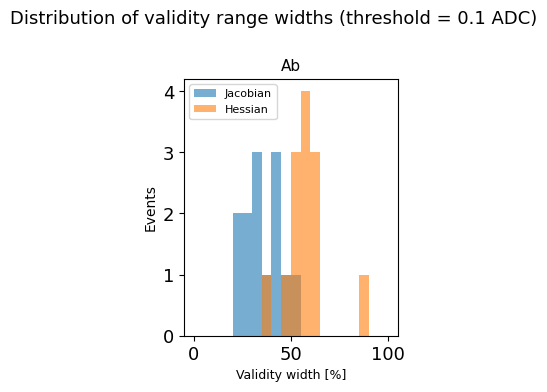

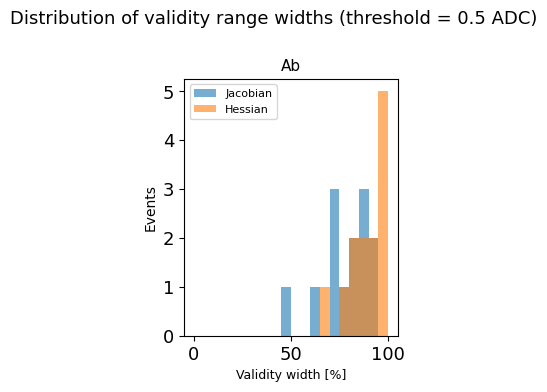

In [6]:
for threshold in THRESHOLDS:
    fig, axes = plt.subplots(1, len(param_names), figsize=(3*len(param_names), 4), sharey=True)
    if len(param_names) == 1:
        axes = [axes]

    for ax, param_name in zip(axes, param_names):
        param_results = results[param_name]
        jac_widths = []
        hess_widths = []
        for eid in sorted(param_results.keys()):
            sr = param_results[eid]
            jr = compute_validity_range(sr['mean_true'], sr['mean_jac'], sr['rel_deltas'], threshold)
            hr = compute_validity_range(sr['mean_true'], sr['mean_hess'], sr['rel_deltas'], threshold)
            jac_widths.append(jr[1] - jr[0])
            hess_widths.append(hr[1] - hr[0])

        bins = np.linspace(0, 100, 21)
        ax.hist(jac_widths, bins=bins, alpha=0.6, color='C0', label='Jacobian')
        ax.hist(hess_widths, bins=bins, alpha=0.6, color='C1', label='Hessian')
        ax.set_xlabel('Validity width [%]', fontsize=9)
        ax.set_title(param_name, fontsize=11)
        if ax == axes[0]:
            ax.set_ylabel('Events', fontsize=10)
            ax.legend(fontsize=8)

    fig.suptitle(f'Distribution of validity range widths (threshold = {threshold} ADC)', fontsize=13)
    fig.tight_layout()
    os.makedirs('plots', exist_ok=True)
    fig.savefig(f'plots/validity_width_dist_{threshold}.pdf', bbox_inches='tight')
    plt.show()


## Validity range summary plot

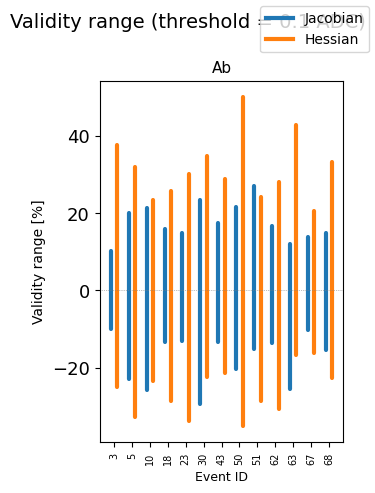

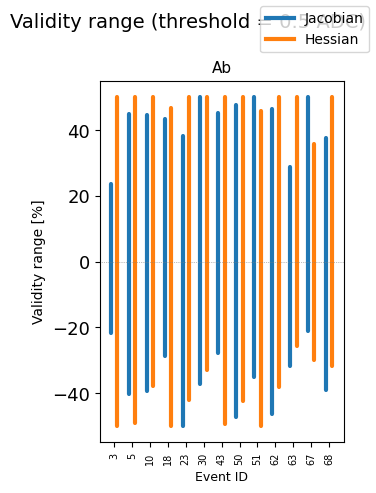

In [8]:
for threshold in THRESHOLDS:
    fig, axes = plt.subplots(1, len(param_names), figsize=(3.5*len(param_names), 5),
                             sharey=True)
    if len(param_names) == 1:
        axes = [axes]

    for ax, param_name in zip(axes, param_names):
        param_results = results[param_name]
        eids = sorted(param_results.keys())
        x = np.arange(len(eids))
        w = 0.35

        jac_lo, jac_hi, hess_lo, hess_hi = [], [], [], []
        for eid in eids:
            sr = param_results[eid]
            jr = compute_validity_range(sr['mean_true'], sr['mean_jac'], sr['rel_deltas'], threshold)
            hr = compute_validity_range(sr['mean_true'], sr['mean_hess'], sr['rel_deltas'], threshold)
            jac_lo.append(jr[0]); jac_hi.append(jr[1])
            hess_lo.append(hr[0]); hess_hi.append(hr[1])

        # Plot as ranges (lo to hi) per event
        for i in x:
            ax.plot([i - w/2, i - w/2], [jac_lo[i], jac_hi[i]], 'C0-', lw=3, solid_capstyle='round')
            ax.plot([i + w/2, i + w/2], [hess_lo[i], hess_hi[i]], 'C1-', lw=3, solid_capstyle='round')

        ax.set_xticks(x)
        ax.set_xticklabels(eids, rotation=90, fontsize=7)
        ax.set_xlabel('Event ID', fontsize=9)
        ax.set_title(param_name, fontsize=11)
        ax.axhline(0, color='gray', ls=':', lw=0.5)

    axes[0].set_ylabel('Validity range [%]', fontsize=10)

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='C0', lw=3, label='Jacobian'),
        Line2D([0], [0], color='C1', lw=3, label='Hessian'),
    ]
    fig.legend(handles=legend_elements, loc='upper right', fontsize=10)
    fig.suptitle(f'Validity range (threshold = {threshold} ADC)', fontsize=14)
    fig.tight_layout()
    fig.savefig(f'plots/validity_range_threshold_{threshold}.pdf', bbox_inches='tight')
    plt.show()